In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

In [3]:
product_sales = pd.read_csv("../content/sales_integrated.csv")

print("Dataset shape:", product_sales.shape)

Dataset shape: (130402, 55)


In [4]:
print(product_sales.head())

print("\nDataset shape:")
print(product_sales.shape)

print("\nColumns:")
print(product_sales.columns.tolist())

       so_id  line_number product_id  quantity  unit_price  gst_rate  \
0  SO-990591            1       P018        19       11300        28   
1  SO-990591            2       P026         2         310        18   
2  SO-990591            3       P026         3         310        18   
3  SO-990591            4       P013         9        1450        18   
4  SO-990591            5       P004         3       39800        28   

   line_total  gst_amount  line_grand_total customer_id  ... pincode region  \
0      214700     60116.0          274816.0       C0070  ...  784913   West   
1         620       111.6             731.6       C0070  ...  784913   West   
2         930       167.4            1097.4       C0070  ...  784913   West   
3       13050      2349.0           15399.0       C0070  ...  784913   West   
4      119400     33432.0          152832.0       C0070  ...  784913   West   

  branch_id_customer credit_limit current_balance  payment_terms_customer  \
0             A

In [5]:
required_columns = [
    "order_date",
    "quantity",
    "line_total",
    "product_id",
    "product_name"
]

missing_columns = [
    col for col in required_columns
    if col not in product_sales.columns
]

if missing_columns:
    print("Missing columns:", missing_columns)
else:
    print("All required columns are available.")

All required columns are available.


In [6]:
week9_data = product_sales.copy()

print("Week 9 dataset shape:", week9_data.shape)

Week 9 dataset shape: (130402, 55)


### **Convert Numeric Columns**

In [7]:
week9_data["quantity"] = pd.to_numeric(
    week9_data["quantity"],
    errors="coerce"
)

week9_data["line_total"] = pd.to_numeric(
    week9_data["line_total"],
    errors="coerce"
)

### **Convert Order Date**

In [8]:
week9_data["order_date"] = pd.to_datetime(
    week9_data["order_date"],
    errors="coerce"
)

print("Start date:", week9_data["order_date"].min())
print("End date:", week9_data["order_date"].max())

Start date: 2019-01-01 00:00:00
End date: 2024-12-31 00:00:00


### **Check Missing Values**

In [9]:
week9_data[
    ["order_date", "quantity", "line_total"]
].isnull().sum()

,0
order_date,0
quantity,0
line_total,0


### **Remove Invalid Forecasting Records**

In [10]:
week9_data = week9_data.dropna(
    subset=[
        "order_date",
        "quantity",
        "line_total"
    ]
).copy()

week9_data = week9_data[
    (week9_data["quantity"] >= 0) &
    (week9_data["line_total"] >= 0)
].copy()

print("Cleaned dataset shape:", week9_data.shape)

Cleaned dataset shape: (130402, 55)


### **MONTHLY SALES ANALYSIS**

### **Create Monthly Sales Dataset**

In [11]:
monthly_sales = (
    week9_data
    .set_index("order_date")
    .resample("ME")
    .agg(
        total_revenue=("line_total", "sum"),
        total_units=("quantity", "sum"),
        total_orders=("so_id", "nunique")
    )
    .reset_index()
)

monthly_sales.head()

,order_date,total_revenue,total_units,total_orders
0,2019-01-31,392951210,19023,286
1,2019-02-28,281974060,15213,237
2,2019-03-31,368326180,19796,294
3,2019-04-30,368885680,19672,281
4,2019-05-31,364324690,20130,285


### **Check Monthly Sales**

In [12]:
monthly_sales.tail()

,order_date,total_revenue,total_units,total_orders
67,2024-08-31,337495540,19486,288
68,2024-09-30,378860380,19800,297
69,2024-10-31,391009730,19525,283
70,2024-11-30,335130770,18462,288
71,2024-12-31,328512840,17540,254


### **Check Number of Months**

In [13]:
print(
    "Number of months:",
    monthly_sales["order_date"].nunique()
)

Number of months: 72


### **Calculate Average Monthly Revenue**

In [14]:
average_monthly_revenue = (
    monthly_sales["total_revenue"].mean()
)

print(
    f"Average monthly revenue: "
    f"£{average_monthly_revenue:,.2f}"
)

Average monthly revenue: £353,436,007.78


### **Calculate Monthly Sales Growth**

In [15]:
monthly_sales["revenue_growth_percentage"] = (
    monthly_sales["total_revenue"]
    .pct_change()
    * 100
)

monthly_sales.head()

,order_date,total_revenue,total_units,total_orders,revenue_growth_percentage
0,2019-01-31,392951210,19023,286,NaN
1,2019-02-28,281974060,15213,237,-28.241967
2,2019-03-31,368326180,19796,294,30.624136
3,2019-04-30,368885680,19672,281,0.151903
4,2019-05-31,364324690,20130,285,-1.236424


### **Calculate Unit Growth**

In [16]:
monthly_sales["unit_growth_percentage"] = (
    monthly_sales["total_units"]
    .pct_change()
    * 100
)

### **Identify Peak Sales Month**

In [17]:
peak_sales_month = monthly_sales.loc[
    monthly_sales["total_revenue"].idxmax()
]

print(
    "Peak sales month:",
    peak_sales_month["order_date"].strftime("%Y-%m")
)

print(
    f"Revenue: £{peak_sales_month['total_revenue']:,.2f}"
)

Peak sales month: 2020-07
Revenue: £429,255,230.00


### **Identify Lowest Sales Month**

In [18]:
lowest_sales_month = monthly_sales.loc[
    monthly_sales["total_revenue"].idxmin()
]

print(
    "Lowest sales month:",
    lowest_sales_month["order_date"].strftime("%Y-%m")
)

print(
    f"Revenue: £{lowest_sales_month['total_revenue']:,.2f}"
)

Lowest sales month: 2019-02
Revenue: £281,974,060.00


### **YEARLY SALES ANALYSIS**

### **Create Yearly Sales Summary**

In [19]:
yearly_sales = (
    week9_data
    .set_index("order_date")
    .resample("YE")
    .agg(
        total_revenue=("line_total", "sum"),
        total_units=("quantity", "sum"),
        total_orders=("so_id", "nunique")
    )
    .reset_index()
)

yearly_sales["year"] = (
    yearly_sales["order_date"].dt.year
)

yearly_sales

,order_date,total_revenue,total_units,total_orders,year
0,2019-12-31,4240155300,227690,3336,2019
1,2020-12-31,4319547190,233662,3358,2020
2,2021-12-31,4250812540,230332,3365,2021
3,2022-12-31,4246716420,225035,3279,2022
4,2023-12-31,4232975380,226927,3346,2023
5,2024-12-31,4157185730,224888,3316,2024


### **Calculate Annual Revenue Growth**

In [20]:
yearly_sales["revenue_growth_percentage"] = (
    yearly_sales["total_revenue"]
    .pct_change()
    * 100
)

yearly_sales

,order_date,total_revenue,total_units,total_orders,year,revenue_growth_percentage
0,2019-12-31,4240155300,227690,3336,2019,NaN
1,2020-12-31,4319547190,233662,3358,2020,1.872382
2,2021-12-31,4250812540,230332,3365,2021,-1.591247
3,2022-12-31,4246716420,225035,3279,2022,-0.096361
4,2023-12-31,4232975380,226927,3346,2023,-0.323569
5,2024-12-31,4157185730,224888,3316,2024,-1.790458


### **SEASONAL ANALYSIS**

### **Create Month Number and Month Name**

In [21]:
monthly_sales["month_number"] = (
    monthly_sales["order_date"].dt.month
)

monthly_sales["month_name"] = (
    monthly_sales["order_date"].dt.month_name()
)

monthly_sales.head()

,order_date,total_revenue,total_units,total_orders,revenue_growth_percentage,unit_growth_percentage,month_number,month_name
0,2019-01-31,392951210,19023,286,NaN,NaN,1,January
1,2019-02-28,281974060,15213,237,-28.241967,-20.028387,2,February
2,2019-03-31,368326180,19796,294,30.624136,30.125551,3,March
3,2019-04-30,368885680,19672,281,0.151903,-0.626389,4,April
4,2019-05-31,364324690,20130,285,-1.236424,2.328182,5,May


### **Calculate Average Revenue by Calendar Month**

In [22]:
seasonal_sales = (
    monthly_sales
    .groupby(
        ["month_number", "month_name"]
    )
    .agg(
        average_revenue=("total_revenue", "mean"),
        average_units=("total_units", "mean"),
        average_orders=("total_orders", "mean")
    )
    .reset_index()
    .sort_values("month_number")
)

seasonal_sales

,month_number,month_name,average_revenue,average_units,average_orders
0,1,January,3.598877e+08,18996.666667,282.666667
1,2,February,3.228458e+08,17345.500000,252.166667
2,3,March,3.590939e+08,19347.500000,280.166667
3,4,April,3.505337e+08,18407.833333,268.500000
4,5,May,3.543996e+08,19352.500000,286.333333
5,6,June,3.427570e+08,18511.833333,269.666667
6,7,July,3.643515e+08,19864.166667,287.166667
7,8,August,3.735901e+08,20393.666667,287.166667
8,9,September,3.568504e+08,19106.666667,281.000000
9,10,October,3.606012e+08,19085.000000,277.333333


### **Identify Highest Seasonal Month**

In [23]:
highest_seasonal_month = seasonal_sales.loc[
    seasonal_sales["average_revenue"].idxmax()
]

print(
    "Highest average sales month:",
    highest_seasonal_month["month_name"]
)

print(
    f"Average revenue: "
    f"£{highest_seasonal_month['average_revenue']:,.2f}"
)

Highest average sales month: August
Average revenue: £373,590,080.00


### **Identify Lowest Seasonal Month**

In [24]:
lowest_seasonal_month = seasonal_sales.loc[
    seasonal_sales["average_revenue"].idxmin()
]

print(
    "Lowest average sales month:",
    lowest_seasonal_month["month_name"]
)

print(
    f"Average revenue: "
    f"£{lowest_seasonal_month['average_revenue']:,.2f}"
)

Lowest average sales month: February
Average revenue: £322,845,793.33


### **PRODUCT DEMAND ANALYSIS**

### **Product-Level Sales**

In [25]:
product_demand = (
    week9_data
    .groupby(
        ["product_id", "product_name"]
    )
    .agg(
        total_units=("quantity", "sum"),
        total_revenue=("line_total", "sum"),
        total_orders=("so_id", "nunique"),
        active_months=("order_date", "nunique")
    )
    .reset_index()
)

product_demand.head()

,product_id,product_name,total_units,total_revenue,total_orders,active_months
0,P001,Hydraulic Pump HP-300,45389,1112030500,3854,1801
1,P002,Engine Oil Filter OF-90,45342,32646240,3861,1819
2,P003,Air Filter AF-120,45684,57105000,3895,1823
3,P004,Track Chain TC-45,45575,1813885000,3781,1820
4,P005,Fuel Injector FI-220,45026,380469700,3840,1798


### **Top Products by Units Sold**

In [26]:
top_products_units = (
    product_demand
    .sort_values(
        "total_units",
        ascending=False
    )
)

top_products_units.head(20)

,product_id,product_name,total_units,total_revenue,total_orders,active_months
28,P029,Pressure Sensor PS-90,47066,185910700,3882,1806
9,P010,Turbocharger TB-900,46964,1639043600,3933,1831
5,P006,Alternator ALT-500,46731,523387200,3936,1811
10,P011,Hydraulic Cylinder HC-200,46612,1286491200,3982,1841
6,P007,Hydraulic Hose HH-60,46468,67378600,3906,1845
20,P021,Boom Cylinder BC-400,46364,2142016800,3873,1801
15,P016,Radiator RD-250,46306,472321200,3934,1831
27,P028,Light Assembly LA-18,46164,103869000,3917,1828
11,P012,Brake Pad BP-40,45972,112631400,3883,1819
18,P019,Swing Motor SWM-350,45971,1829645800,3849,1795


### **Top Products by Revenue**

In [27]:
top_products_revenue = (
    product_demand
    .sort_values(
        "total_revenue",
        ascending=False
    )
)

top_products_revenue.head(20)

,product_id,product_name,total_units,total_revenue,total_orders,active_months
14,P015,Engine Block EB-600,45222,5381418000,3773,1811
13,P014,Transmission Assembly TA-800,45035,3760422500,3838,1796
20,P021,Boom Cylinder BC-400,46364,2142016800,3873,1801
18,P019,Swing Motor SWM-350,45971,1829645800,3849,1795
3,P004,Track Chain TC-45,45575,1813885000,3781,1820
9,P010,Turbocharger TB-900,46964,1639043600,3933,1831
10,P011,Hydraulic Cylinder HC-200,46612,1286491200,3982,1841
0,P001,Hydraulic Pump HP-300,45389,1112030500,3854,1801
29,P030,Fuel Pump FP-350,45897,1005144300,3856,1812
21,P022,Control Valve CV-75,45819,774341100,3892,1819


### **PRODUCT DEMAND TRENDS**

### **Monthly Product Sales**

In [28]:
monthly_product_sales = (
    week9_data
    .set_index("order_date")
    .groupby("product_id")
    .resample("ME")
    .agg(
        units_sold=("quantity", "sum"),
        revenue=("line_total", "sum")
    )
    .reset_index()
)

monthly_product_sales.head()

,product_id,order_date,units_sold,revenue
0,P001,2019-01-31,513,12568500
1,P001,2019-02-28,429,10510500
2,P001,2019-03-31,642,15729000
3,P001,2019-04-30,549,13450500
4,P001,2019-05-31,748,18326000


### **Select Top 5 Products**

In [29]:
top_5_products = (
    product_demand
    .sort_values(
        "total_revenue",
        ascending=False
    )
    .head(5)["product_id"]
    .tolist()
)

top_5_products

['P015', 'P014', 'P021', 'P019', 'P004']

### **Filter Top Product Trends**

In [30]:
top_product_trends = monthly_product_sales[
    monthly_product_sales["product_id"].isin(
        top_5_products
    )
].copy()

top_product_trends.head()

,product_id,order_date,units_sold,revenue
216,P004,2019-01-31,865,34427000
217,P004,2019-02-28,517,20576600
218,P004,2019-03-31,626,24914800
219,P004,2019-04-30,770,30646000
220,P004,2019-05-31,577,22964600


### **TIME-SERIES PREPARATION**

### **Create Revenue Time Series**

In [31]:
revenue_series = (
    monthly_sales[
        ["order_date", "total_revenue"]
    ]
    .set_index("order_date")
    ["total_revenue"]
)

revenue_series = revenue_series.asfreq("ME")

print(revenue_series.head())
print("\nNumber of observations:", len(revenue_series))

order_date
2019-01-31    392951210
2019-02-28    281974060
2019-03-31    368326180
2019-04-30    368885680
2019-05-31    364324690
Freq: ME, Name: total_revenue, dtype: int64

Number of observations: 72


### **Check Missing Months**

In [32]:
print(
    "Missing monthly values:",
    revenue_series.isna().sum()
)

Missing monthly values: 0


### **TRAIN / TEST SPLIT**

## **Determine Forecast Test Period**<br>

We will reserve the last 20% of observations for testing.

In [33]:
split_index = int(
    len(revenue_series) * 0.80
)

train = revenue_series.iloc[:split_index]

test = revenue_series.iloc[split_index:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 57
Testing observations: 15


### **Display Training and Testing Dates**

In [34]:
print("Training period:")
print(train.index.min(), "to", train.index.max())

print("\nTesting period:")
print(test.index.min(), "to", test.index.max())

Training period:
2019-01-31 00:00:00 to 2023-09-30 00:00:00

Testing period:
2023-10-31 00:00:00 to 2024-12-31 00:00:00


### **BASELINE MODEL**

### **Naive Forecast**<br>

A simple baseline predicts that the next period will be equal to the previous period.

In [35]:
naive_forecast = pd.Series(
    train.iloc[-1],
    index=test.index
)

naive_mae = mean_absolute_error(
    test,
    naive_forecast
)

naive_rmse = np.sqrt(
    mean_squared_error(
        test,
        naive_forecast
    )
)

print(f"Naive MAE: £{naive_mae:,.2f}")
print(f"Naive RMSE: £{naive_rmse:,.2f}")

Naive MAE: £36,517,689.33
Naive RMSE: £40,295,581.72


### **EXPONENTIAL SMOOTHING**<br>


### **Fit Exponential Smoothing Model**

In [36]:
try:
    ets_model = ExponentialSmoothing(
        train,
        trend="add",
        seasonal="add",
        seasonal_periods=12,
        initialization_method="estimated"
    ).fit()

    ets_forecast = ets_model.forecast(
        len(test)
    )

    print("Exponential Smoothing model fitted successfully.")

except Exception as e:
    print("Seasonal model could not be fitted:")
    print(e)

Exponential Smoothing model fitted successfully.


### **Evaluate Exponential Smoothing**

In [37]:
ets_mae = mean_absolute_error(
    test,
    ets_forecast
)

ets_rmse = np.sqrt(
    mean_squared_error(
        test,
        ets_forecast
    )
)

print(f"Exponential Smoothing MAE: £{ets_mae:,.2f}")
print(f"Exponential Smoothing RMSE: £{ets_rmse:,.2f}")

Exponential Smoothing MAE: £29,415,487.71
Exponential Smoothing RMSE: £34,072,633.90


### **ARIMA MODEL**

### **Fit ARIMA**

In [38]:
arima_model = ARIMA(
    train,
    order=(1, 1, 1)
)

arima_result = arima_model.fit()

arima_forecast = arima_result.forecast(
    steps=len(test)
)

print("ARIMA model fitted successfully.")

ARIMA model fitted successfully.


## **Evaluate ARIMA**

In [39]:
arima_mae = mean_absolute_error(
    test,
    arima_forecast
)

arima_rmse = np.sqrt(
    mean_squared_error(
        test,
        arima_forecast
    )
)

print(f"ARIMA MAE: £{arima_mae:,.2f}")
print(f"ARIMA RMSE: £{arima_rmse:,.2f}")

ARIMA MAE: £35,783,217.06
ARIMA RMSE: £39,562,232.96


### **MODEL COMPARISON**

### **Create Model Comparison Table**

In [40]:
model_comparison = pd.DataFrame({
    "Model": [
        "Naive",
        "Exponential Smoothing",
        "ARIMA"
    ],
    "MAE": [
        naive_mae,
        ets_mae,
        arima_mae
    ],
    "RMSE": [
        naive_rmse,
        ets_rmse,
        arima_rmse
    ]
})

model_comparison

,Model,MAE,RMSE
0,Naive,3.651769e+07,4.029558e+07
1,Exponential Smoothing,2.941549e+07,3.407263e+07
2,ARIMA,3.578322e+07,3.956223e+07


### **Sort Models by MAE**

In [41]:
model_comparison.sort_values(
    "MAE"
)

,Model,MAE,RMSE
1,Exponential Smoothing,2.941549e+07,3.407263e+07
2,ARIMA,3.578322e+07,3.956223e+07
0,Naive,3.651769e+07,4.029558e+07


### **Identify Best Model**

In [42]:
best_model_row = model_comparison.loc[
    model_comparison["MAE"].idxmin()
]

best_model = best_model_row["Model"]

print(
    "Best forecasting model based on MAE:",
    best_model
)

print(
    f"MAE: £{best_model_row['MAE']:,.2f}"
)

Best forecasting model based on MAE: Exponential Smoothing
MAE: £29,415,487.71


### **ACTUAL VS FORECAST**

### **Plot Model Forecasts**

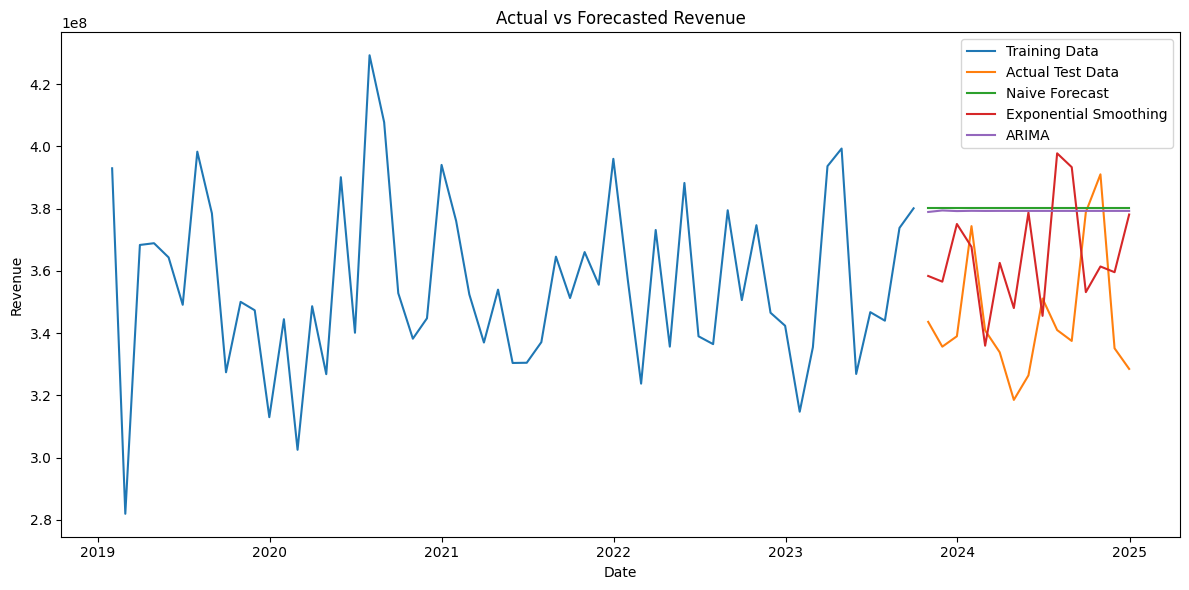

In [43]:
plt.figure(figsize=(12, 6))

plt.plot(
    train.index,
    train.values,
    label="Training Data"
)

plt.plot(
    test.index,
    test.values,
    label="Actual Test Data"
)

plt.plot(
    test.index,
    naive_forecast.values,
    label="Naive Forecast"
)

plt.plot(
    test.index,
    ets_forecast.values,
    label="Exponential Smoothing"
)

plt.plot(
    test.index,
    arima_forecast.values,
    label="ARIMA"
)

plt.xlabel("Date")
plt.ylabel("Revenue")
plt.title("Actual vs Forecasted Revenue")

plt.legend()

plt.tight_layout()
plt.show()

### **SELECT BEST MODEL**

### **Generate Future Forecast**<br>

We will forecast the next 6 months.

In [44]:
forecast_horizon = 6

### **Refit Best Model on Full Dataset**

In [45]:
if best_model == "Naive":

    final_forecast = pd.Series(
        revenue_series.iloc[-1],
        index=pd.date_range(
            start=revenue_series.index[-1] + pd.offsets.MonthEnd(1),
            periods=forecast_horizon,
            freq="ME"
        )
    )

elif best_model == "Exponential Smoothing":

    final_model = ExponentialSmoothing(
        revenue_series,
        trend="add",
        seasonal="add",
        seasonal_periods=12,
        initialization_method="estimated"
    ).fit()

    final_forecast = final_model.forecast(
        forecast_horizon
    )

else:

    final_model = ARIMA(
        revenue_series,
        order=(1, 1, 1)
    ).fit()

    final_forecast = final_model.forecast(
        steps=forecast_horizon
    )

final_forecast

,0
2025-01-31,3.407833e+08
2025-02-28,3.215926e+08
2025-03-31,3.552769e+08
2025-04-30,3.452771e+08
2025-05-31,3.500754e+08
2025-06-30,3.297413e+08


### **FUTURE FORECAST TABLE**

### **Create Forecast DataFrame**

In [46]:
forecast_df = pd.DataFrame({
    "forecast_date": final_forecast.index,
    "forecasted_revenue": final_forecast.values
})

forecast_df

,forecast_date,forecasted_revenue
0,2025-01-31,3.407833e+08
1,2025-02-28,3.215926e+08
2,2025-03-31,3.552769e+08
3,2025-04-30,3.452771e+08
4,2025-05-31,3.500754e+08
5,2025-06-30,3.297413e+08


### **Calculate Total Forecast Revenue**

In [47]:
total_forecast_revenue = (
    forecast_df["forecasted_revenue"].sum()
)

print(
    f"Forecasted revenue for next "
    f"{forecast_horizon} months: "
    f"£{total_forecast_revenue:,.2f}"
)

Forecasted revenue for next 6 months: £2,042,746,636.04


### **Calculate Average Forecast Revenue**

In [48]:
average_forecast_revenue = (
    forecast_df["forecasted_revenue"].mean()
)

print(
    f"Average forecasted monthly revenue: "
    f"£{average_forecast_revenue:,.2f}"
)

Average forecasted monthly revenue: £340,457,772.67


### **FORECAST VISUALISATION**

### **Historical and Future Forecast**

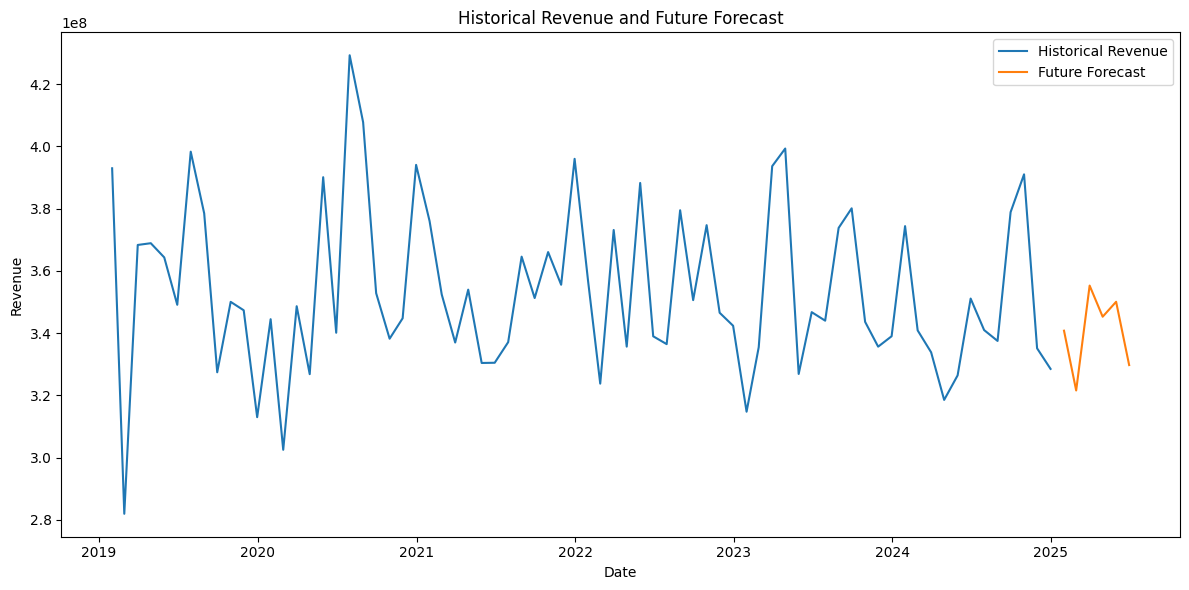

In [49]:
plt.figure(figsize=(12, 6))

plt.plot(
    revenue_series.index,
    revenue_series.values,
    label="Historical Revenue"
)

plt.plot(
    forecast_df["forecast_date"],
    forecast_df["forecasted_revenue"],
    label="Future Forecast"
)

plt.xlabel("Date")
plt.ylabel("Revenue")
plt.title("Historical Revenue and Future Forecast")

plt.legend()

plt.tight_layout()
plt.show()

### **PRODUCT VISUALISATIONS**

### **Top Products by Revenue**

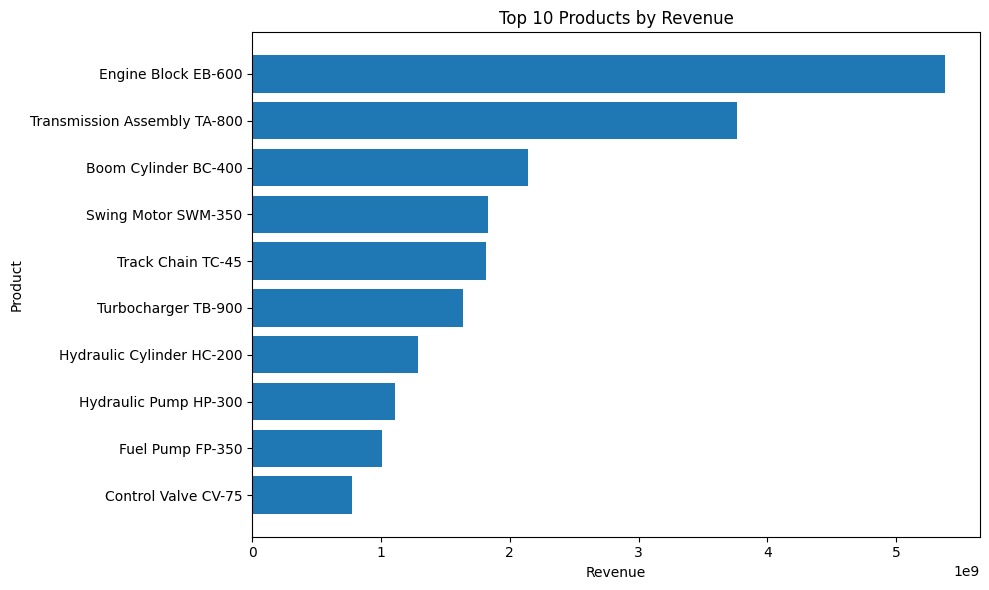

In [50]:
top10 = (
    product_demand
    .sort_values(
        "total_revenue",
        ascending=False
    )
    .head(10)
    .sort_values("total_revenue")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10["product_name"].astype(str),
    top10["total_revenue"]
)

plt.xlabel("Revenue")
plt.ylabel("Product")
plt.title("Top 10 Products by Revenue")

plt.tight_layout()
plt.show()

### **Top Products by Units**

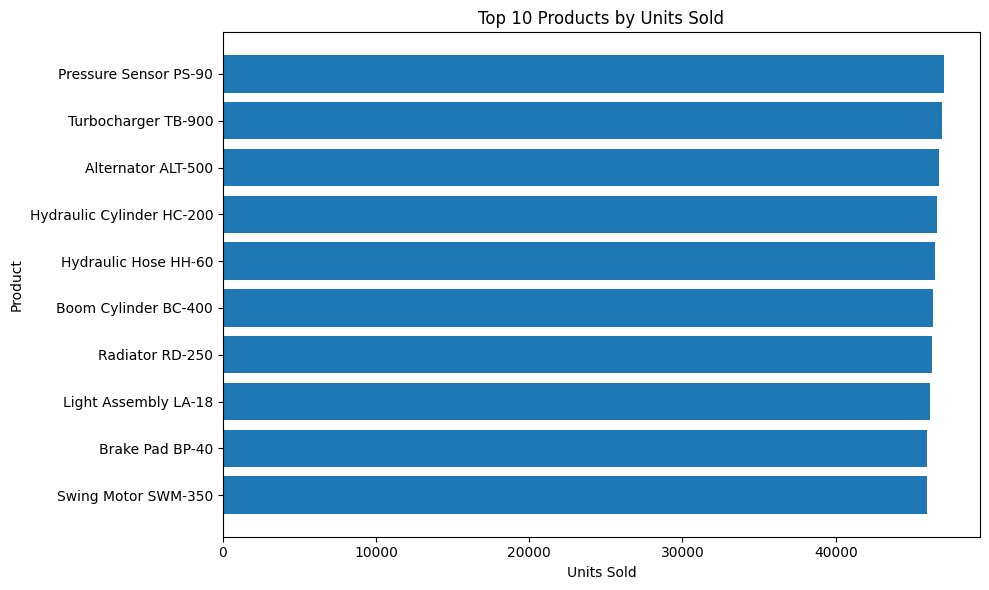

In [51]:
top10_units = (
    product_demand
    .sort_values(
        "total_units",
        ascending=False
    )
    .head(10)
    .sort_values("total_units")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10_units["product_name"].astype(str),
    top10_units["total_units"]
)

plt.xlabel("Units Sold")
plt.ylabel("Product")
plt.title("Top 10 Products by Units Sold")

plt.tight_layout()
plt.show()

### **Monthly Revenue Trend**

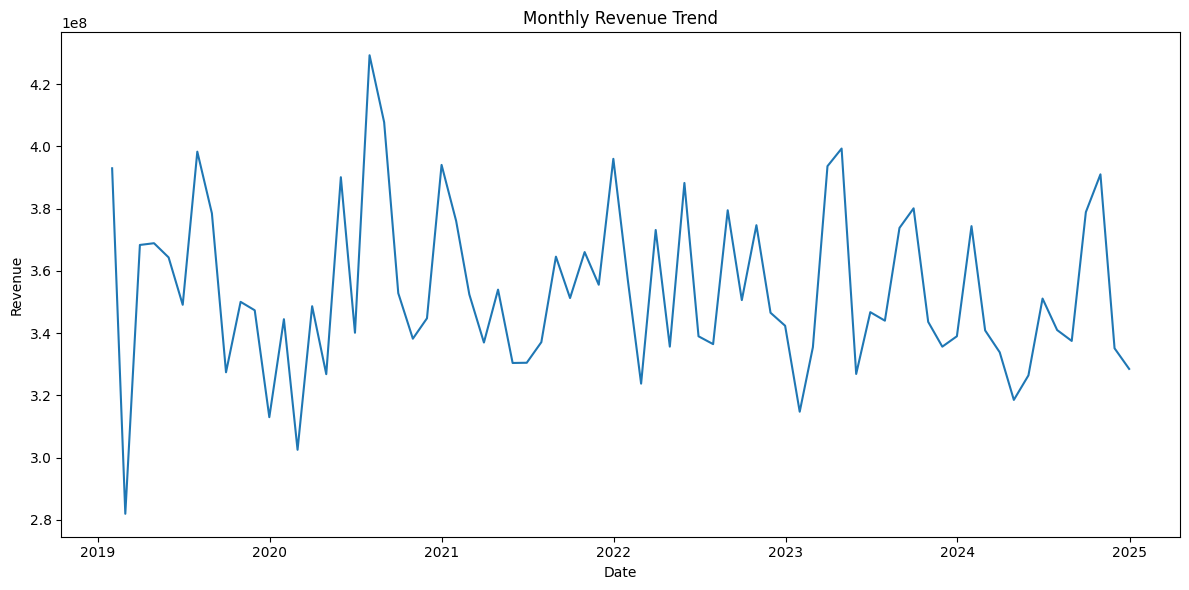

In [52]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["order_date"],
    monthly_sales["total_revenue"]
)

plt.xlabel("Date")
plt.ylabel("Revenue")
plt.title("Monthly Revenue Trend")

plt.tight_layout()
plt.show()

### **Monthly Revenue Growth**

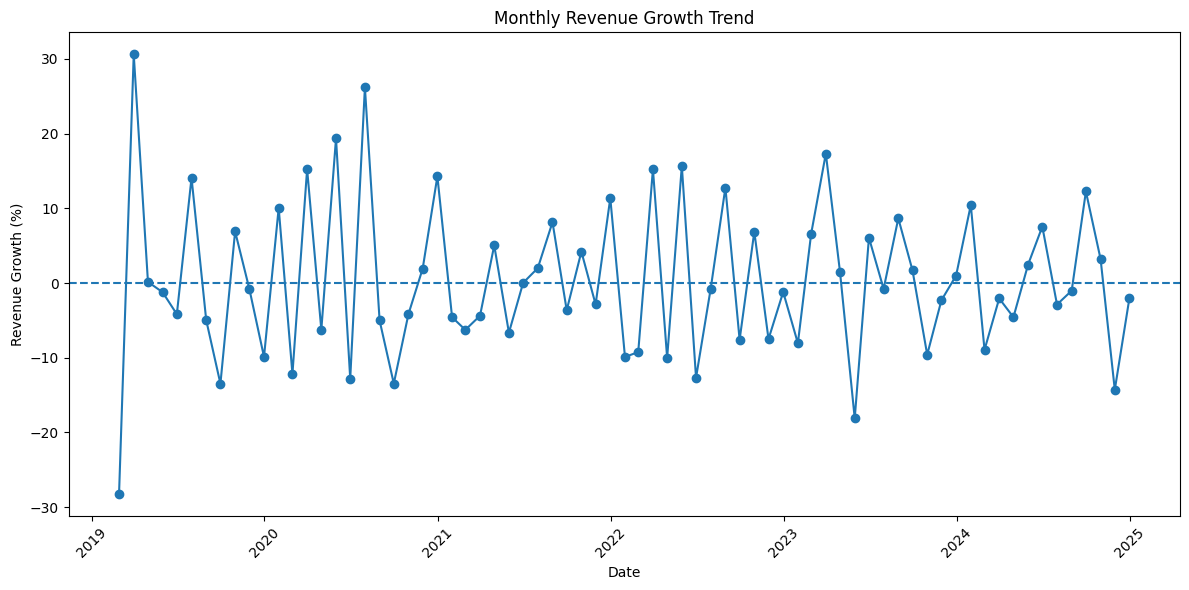

In [53]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["order_date"],
    monthly_sales["revenue_growth_percentage"],
    marker="o"
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Date")
plt.ylabel("Revenue Growth (%)")
plt.title("Monthly Revenue Growth Trend")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### **Seasonal Revenue Pattern**

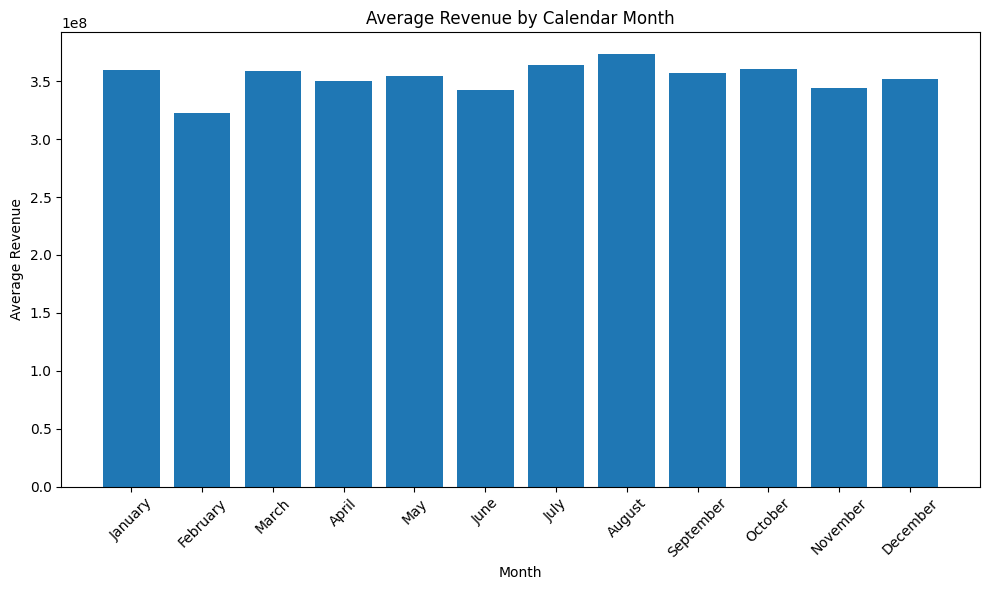

In [54]:
plt.figure(figsize=(10, 6))

plt.bar(
    seasonal_sales["month_name"],
    seasonal_sales["average_revenue"]
)

plt.xlabel("Month")
plt.ylabel("Average Revenue")
plt.title("Average Revenue by Calendar Month")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### **Top Product Demand Trends**

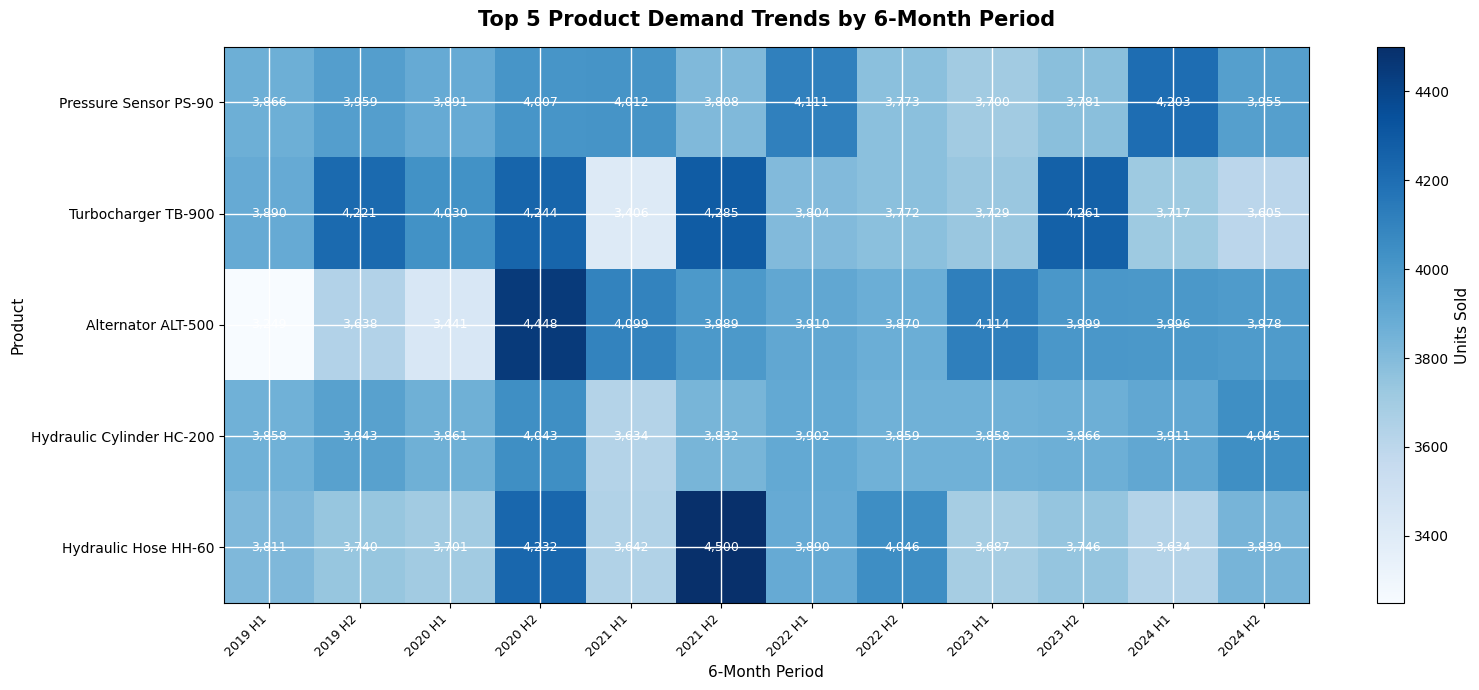

In [57]:
# Calculate total units sold by product
product_demand = (
    week9_data
    .groupby(["product_id", "product_name"], as_index=False)
    .agg(
        total_units_sold=("quantity", "sum")
    )
)

# Select top 5 products by total units sold
top_5_products = (
    product_demand
    .nlargest(5, "total_units_sold")
)

top_product_ids = top_5_products["product_id"].tolist()

# Create 6-month periods
week9_data["half_year"] = (
    week9_data["order_date"].dt.year.astype(str)
    + " H"
    + np.where(
        week9_data["order_date"].dt.month <= 6,
        "1",
        "2"
    )
)

# Calculate units sold for each product in each 6-month period
top_product_6month = (
    week9_data[
        week9_data["product_id"].isin(top_product_ids)
    ]
    .groupby(
        ["half_year", "product_id", "product_name"],
        as_index=False
    )
    .agg(
        units_sold=("quantity", "sum")
    )
)

# Create product × 6-month matrix
demand_matrix = top_product_6month.pivot_table(
    index="product_name",
    columns="half_year",
    values="units_sold",
    fill_value=0
)

# Sort columns chronologically
demand_matrix = demand_matrix.reindex(
    columns=sorted(demand_matrix.columns)
)

# Keep products ordered by total demand
product_order = (
    top_5_products
    .sort_values("total_units_sold", ascending=False)
    ["product_name"]
    .tolist()
)

demand_matrix = demand_matrix.reindex(product_order)

# Plot heatmap
plt.figure(figsize=(16, 7))

im = plt.imshow(
    demand_matrix,
    aspect="auto",
    interpolation="nearest",
    cmap="Blues"
)

# Add colorbar
cbar = plt.colorbar(im)
cbar.set_label("Units Sold", fontsize=11)

# Add product labels
plt.yticks(
    range(len(demand_matrix.index)),
    demand_matrix.index,
    fontsize=10
)

# Add period labels
plt.xticks(
    range(len(demand_matrix.columns)),
    demand_matrix.columns,
    rotation=45,
    ha="right",
    fontsize=9
)

# Add values inside cells
for i in range(len(demand_matrix.index)):
    for j in range(len(demand_matrix.columns)):

        value = demand_matrix.iloc[i, j]

        # Use white text for darker cells
        text_color = "white" if value > demand_matrix.values.max() * 0.55 else "black"

        plt.text(
            j,
            i,
            f"{int(value):,}",
            ha="center",
            va="center",
            fontsize=9,
            color=text_color
        )

plt.xlabel("6-Month Period", fontsize=11)
plt.ylabel("Product", fontsize=11)

plt.title(
    "Top 5 Product Demand Trends by 6-Month Period",
    fontsize=15,
    fontweight="bold",
    pad=15
)

# Add light grid between cells
plt.grid(
    which="major",
    color="white",
    linestyle="-",
    linewidth=1
)

plt.tight_layout()
plt.show()

### **FINAL KPI TABLE**

### **Calculate Week 9 KPIs**

In [58]:
week9_kpis = {
    "Total Historical Revenue":
        week9_data["line_total"].sum(),

    "Total Units Sold":
        week9_data["quantity"].sum(),

    "Total Orders":
        week9_data["so_id"].nunique(),

    "Average Monthly Revenue":
        monthly_sales["total_revenue"].mean(),

    "Peak Sales Month":
        peak_sales_month["order_date"].strftime("%Y-%m"),

    "Peak Monthly Revenue":
        peak_sales_month["total_revenue"],

    "Lowest Sales Month":
        lowest_sales_month["order_date"].strftime("%Y-%m"),

    "Lowest Monthly Revenue":
        lowest_sales_month["total_revenue"],

    "Forecast Horizon (Months)":
        forecast_horizon,

    "Forecasted Revenue":
        total_forecast_revenue,

    "Average Forecasted Monthly Revenue":
        average_forecast_revenue,

    "Best Forecasting Model":
        best_model,

    "Best Model MAE":
        best_model_row["MAE"],

    "Best Model RMSE":
        best_model_row["RMSE"]
}

week9_kpis

{'Total Historical Revenue': np.int64(25447392560),
 'Total Units Sold': np.int64(1368534),
 'Total Orders': 20000,
 'Average Monthly Revenue': np.float64(353436007.7777778),
 'Peak Sales Month': '2020-07',
 'Peak Monthly Revenue': np.int64(429255230),
 'Lowest Sales Month': '2019-02',
 'Lowest Monthly Revenue': np.int64(281974060),
 'Forecast Horizon (Months)': 6,
 'Forecasted Revenue': np.float64(2042746636.0374198),
 'Average Forecasted Monthly Revenue': np.float64(340457772.6729033),
 'Best Forecasting Model': 'Exponential Smoothing',
 'Best Model MAE': np.float64(29415487.706447963),
 'Best Model RMSE': np.float64(34072633.90270184)}

### **Create KPI DataFrame**

In [59]:
week9_kpi_table = pd.DataFrame(
    list(week9_kpis.items()),
    columns=["KPI", "Value"]
)

week9_kpi_table

,KPI,Value
0,Total Historical Revenue,25447392560
1,Total Units Sold,1368534
2,Total Orders,20000
3,Average Monthly Revenue,353436007.777778
4,Peak Sales Month,2020-07
5,Peak Monthly Revenue,429255230
6,Lowest Sales Month,2019-02
7,Lowest Monthly Revenue,281974060
8,Forecast Horizon (Months),6
9,Forecasted Revenue,2042746636.03742


### **EXPORT FILES**

In [60]:
analysis_dir = Path("../analysis")
visual_dir = Path("../visualisations")

analysis_dir.mkdir(
    parents=True,
    exist_ok=True
)

visual_dir.mkdir(
    parents=True,
    exist_ok=True
)

In [61]:
monthly_sales.to_csv(
    analysis_dir / "monthly_sales_analysis.csv",
    index=False
)

yearly_sales.to_csv(
    analysis_dir / "yearly_sales_analysis.csv",
    index=False
)

seasonal_sales.to_csv(
    analysis_dir / "sales_seasonality.csv",
    index=False
)

product_demand.to_csv(
    analysis_dir / "product_demand_analysis.csv",
    index=False
)

model_comparison.to_csv(
    analysis_dir / "forecast_model_comparison.csv",
    index=False
)

forecast_df.to_csv(
    analysis_dir / "future_sales_forecast.csv",
    index=False
)

week9_kpi_table.to_csv(
    analysis_dir / "week9_sales_forecasting_kpis.csv",
    index=False
)

### **FINAL SUMMARY**

In [62]:
print("=" * 60)
print("WEEK 09 — SALES FORECASTING & DEMAND ANALYSIS")
print("=" * 60)

print(
    f"Total historical revenue: "
    f"£{week9_data['line_total'].sum():,.2f}"
)

print(
    f"Total units sold: "
    f"{week9_data['quantity'].sum():,.0f}"
)

print(
    f"Total orders: "
    f"{week9_data['so_id'].nunique():,}"
)

print(
    f"Average monthly revenue: "
    f"£{monthly_sales['total_revenue'].mean():,.2f}"
)

print(
    f"Peak sales month: "
    f"{peak_sales_month['order_date'].strftime('%Y-%m')}"
)

print(
    f"Lowest sales month: "
    f"{lowest_sales_month['order_date'].strftime('%Y-%m')}"
)

print(
    f"Forecast horizon: "
    f"{forecast_horizon} months"
)

print(
    f"Forecasted revenue: "
    f"£{total_forecast_revenue:,.2f}"
)

print(
    f"Best forecasting model: "
    f"{best_model}"
)

print(
    f"Best model MAE: "
    f"£{best_model_row['MAE']:,.2f}"
)

print(
    f"Best model RMSE: "
    f"£{best_model_row['RMSE']:,.2f}"
)

print("=" * 60)
print("Week 09 analysis completed.")

WEEK 09 — SALES FORECASTING & DEMAND ANALYSIS
Total historical revenue: £25,447,392,560.00
Total units sold: 1,368,534
Total orders: 20,000
Average monthly revenue: £353,436,007.78
Peak sales month: 2020-07
Lowest sales month: 2019-02
Forecast horizon: 6 months
Forecasted revenue: £2,042,746,636.04
Best forecasting model: Exponential Smoothing
Best model MAE: £29,415,487.71
Best model RMSE: £34,072,633.90
Week 09 analysis completed.
